In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")

frames = []
for csv_path in DATA_DIR.glob("*/*/data.csv"):
    date = csv_path.parents[1].name
    name = csv_path.parents[0].name

    df_part = pd.read_csv(csv_path, index_col=0)
    # print(df_part)
    df_part["name"] = name
    df_part["date"] = pd.to_datetime(date)
    frames.append(df_part)

df = pd.concat(frames, ignore_index=True)
df = df[["product_id", "quantity", "name", "date"]]

df

   product_id  quantity
0          20         3
1           7         1
   product_id  quantity
0          74         3
1           6         4
   product_id  quantity
0           8         5
1          23         2
2          45         5
3          92         3
   product_id  quantity
0          50         5
1          16         5
2          34         2
3          21         1
   product_id  quantity
0          66         5
1          12         2
2          61         4
   product_id  quantity
0          18         4
1          94         4
   product_id  quantity
0          54         1
1          77         3
2          99         4
3          15         1
   product_id  quantity
0          13         4
1          27         5
2          34         2
3          40         2
4          77         1
5          90         3
   product_id  quantity
0          95         2
1          83         3
2          64         1
   product_id  quantity
0          15         4
   product_id  q

,product_id,quantity,name,date
0,20,3,Alexey_Smirnov,2020-12-07
1,7,1,Alexey_Smirnov,2020-12-07
2,74,3,Kirill_Fedorov,2020-12-07
3,6,4,Kirill_Fedorov,2020-12-07
4,8,5,Anton_Smirnov,2020-12-07
...,...,...,...,...
156,73,5,Alexey_Fedorov,2020-12-08
157,34,1,Alexey_Fedorov,2020-12-08
158,71,1,Alexey_Fedorov,2020-12-08
159,18,2,Alexey_Fedorov,2020-12-08


In [3]:
total_by_user = df.groupby("name", as_index=True)["quantity"].sum()
max_total = total_by_user.max()
winners = sorted(total_by_user[total_by_user == max_total].index.tolist())

answer = ", ".join(winners)
answer

'Alexey_Smirnov, Petr_Smirnov'

/tmp/ipykernel_31778/144542739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(new_df, palette="viridis")


<Axes: xlabel='product_id', ylabel='quantity'>

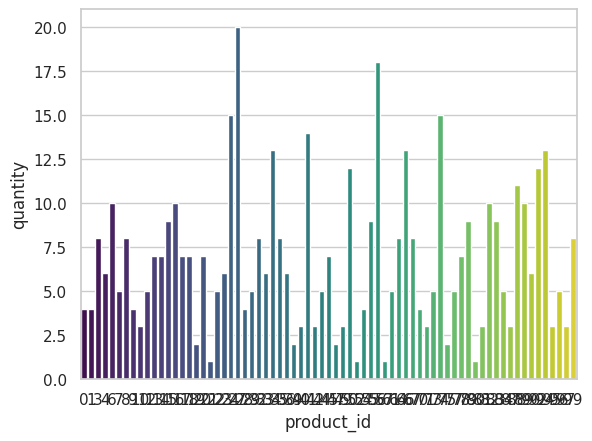

In [19]:
new_df = df.groupby('product_id')['quantity'].sum()
# sns.set_style("darkgrid")
sns.set_theme(style="whitegrid") # Светлая сетка, приятная для глаз
sns.color_palette("flare", as_cmap=True)
sns.barplot(new_df, palette="viridis")
# sns.barplot(new_df)



/tmp/ipykernel_31778/2276632286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(d, palette="icefire")


<Axes: xlabel='product_id', ylabel='quantity'>

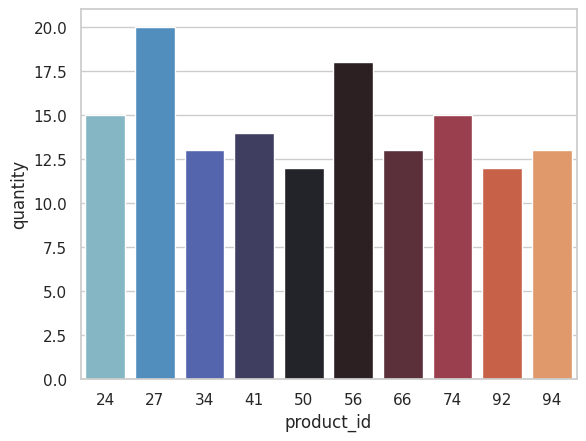

In [34]:
d =new_df.sort_values(ascending=False).head(10)
sns.barplot(d, palette="icefire")

In [39]:
user_product_days = df.groupby(['name', 'product_id'])['date'].nunique()
user_product_days

name            product_id
Alexey_Fedorov  13            1
                15            1
                18            1
                34            1
                50            1
                             ..
Vasiliy_Ivanov  83            1
                94            1
                95            1
Vasiliy_Petrov  27            1
                78            1
Name: date, Length: 158, dtype: int64

In [41]:
repeat_purchases = user_product_days[user_product_days > 1]

unique_repeat_users = repeat_purchases.index.get_level_values('name').nunique()

unique_repeat_users

2

In [42]:
print(f"Количество пользователей с повторными покупками: {unique_repeat_users}")

Количество пользователей с повторными покупками: 2
